# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

0. **Nama Dataset**: AirQualityJakartaData.csv (Jakarta Air Quality Data 2023 : Yoga Rusydi Arifin)

1. **Sumber Dataset**:  
   https://www.kaggle.com/datasets/yogaarifin/jakarta-air-quality-data  

2. **Deskripsi Dataset**:
    Dataset ini berisi data kualitas udara Jakarta dengan parameter seperti PM10, SO2, CO, O3, NO2. Tujuan eksperimen ini adalah memprediksi kategori kualitas udara (Baik/Sedang/Tidak Sehat) berdasarkan parameter kimia tersebut.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Konfigurasi visualisasi agar rapi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Library berhasil diimport.")

Library berhasil diimport.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
file_path = "AirQualityJakartaData.csv"

try:
    df = pd.read_csv(file_path)

    # LANGKAH KRUSIAL: Bersihkan nama kolom dari spasi
    df.columns = [c.strip() for c in df.columns]

    # Mapping nama kolom agar standar (huruf kecil semua)
    col_mapping = {
        'PM10': 'pm10', 'PM25': 'pm25', 'SO2': 'so2',
        'CO': 'co', 'O3': 'o3', 'NO2': 'no2',
        'category': 'category', 'station': 'station', 'date': 'date'
    }
    df = df.rename(columns=col_mapping)

    print("Data berhasil dimuat!")
    print(f"Dimensi Data: {df.shape}")
    display(df.head())

except FileNotFoundError:
    print("File tidak ditemukan. Pastikan path file benar.")

Data berhasil dimuat!
Dimensi Data: (1825, 13)


,_id,data_period,date,station,pm10,pm25,so2,co,o3,no2,max,critical_pollutant_parameter,category
0,1,202302,2023-02-25T00:00:00,DKI5 Kebon Jeruk Jakarta Barat,35,-,13,12,31,18,35,PM10,GOOD
1,2,202302,2023-02-26T00:00:00,DKI5 Kebon Jeruk Jakarta Barat,23,-,14,9,32,11,32,O3,GOOD
2,3,202302,2023-02-27T00:00:00,DKI5 Kebon Jeruk Jakarta Barat,20,-,13,8,33,13,33,O3,GOOD
3,4,202302,2023-02-28T00:00:00,DKI5 Kebon Jeruk Jakarta Barat,30,-,21,11,28,18,30,PM10,GOOD
4,5,202303,2023-03-01T00:00:00,DKI1 Bunderan HI,38,44,50,8,19,27,50,3,GOOD


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Info Tipe Data Awal ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   _id                           1825 non-null   int64 
 1   data_period                   1825 non-null   int64 
 2   date                          1825 non-null   object
 3   station                       1825 non-null   object
 4   pm10                          1825 non-null   object
 5   pm25                          1825 non-null   object
 6   so2                           1825 non-null   object
 7   co                            1825 non-null   object
 8   o3                            1825 non-null   object
 9   no2                           1825 non-null   object
 10  max                           1825 non-null   object
 11  critical_pollutant_parameter  1812 non-null   object
 12  category                      1825 non-null   ob

/tmp/ipython-input-3208285512.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette='viridis')


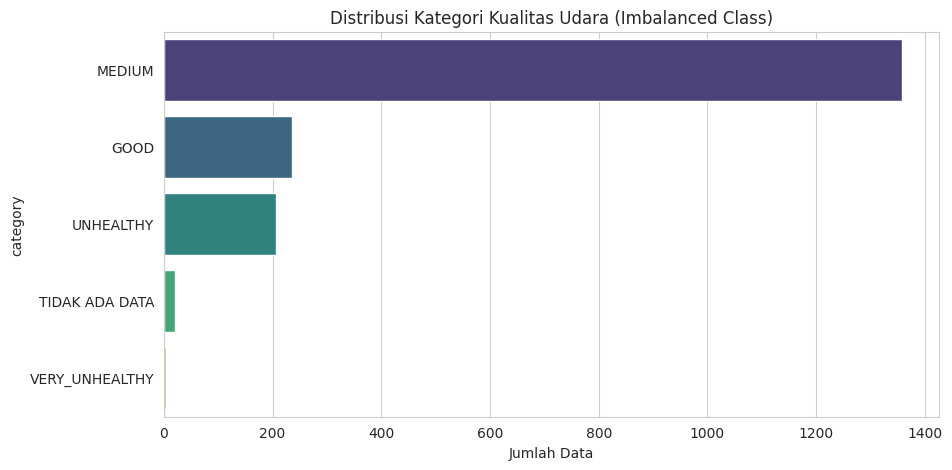


--- Nilai Unik di Kolom Target ---
['GOOD' 'MEDIUM' 'TIDAK ADA DATA' 'UNHEALTHY' 'VERY_UNHEALTHY']


In [ ]:
# 1. Cek Informasi Tipe Data (Perhatikan kolom polutan jadi 'object')
print("--- Info Tipe Data Awal ---")
print(df.info())

# 2. Deteksi 'Dirty Data' (Nilai strip '-')
pollutants = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']
print("\n--- Jumlah Nilai '-' (Strip) per Kolom ---")
for col in pollutants:
    bad_count = df[col].astype(str).value_counts().get('-', 0)
    print(f"{col}: {bad_count} data rusak")

# 3. Visualisasi Distribusi Target (Cek Imbalance)
plt.figure(figsize=(10, 5))
sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette='viridis')
plt.title("Distribusi Kategori Kualitas Udara (Imbalanced Class)")
plt.xlabel("Jumlah Data")
plt.show()

# 4. Cek Konsistensi Nama Kategori (Apakah ada 'TIDAK ADA DATA'?)
print("\n--- Nilai Unik di Kolom Target ---")
print(df['category'].unique())

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# Buat copy agar data asli aman
df_clean = df.copy()

# A. Handling Dirty Values & Type Conversion
for col in pollutants:
    df_clean[col] = df_clean[col].astype(str).replace(["-", "---", ""], np.nan)
    # Paksa ubah ke tipe numerik (Float)
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# B. Handling Missing Values (Imputation)
for col in pollutants:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

# C. Handling Target (Category)
df_clean = df_clean[df_clean['category'] != 'TIDAK ADA DATA']
df_clean = df_clean.dropna(subset=['category'])

# 2. Standarisasi Teks (Huruf Besar semua)
df_clean['category'] = df_clean['category'].str.upper().str.strip().str.replace(' ', '_')

# 3. Label Encoding (Ubah Text jadi Angka 0, 1, 2...)
label_map = {
    'GOOD': 0,
    'MEDIUM': 1,
    'UNHEALTHY': 2,
    'VERY_UNHEALTHY': 3,
    'HAZARDOUS': 4
}
# Filter hanya data yang ada di map
df_clean = df_clean[df_clean['category'].isin(label_map.keys())]
df_clean['target'] = df_clean['category'].map(label_map)

print("--- Data Setelah Cleaning ---")
print(df_clean.info())
print("\nContoh 5 baris data bersih:")
display(df_clean.head())

# D. Feature Selection & Splitting
features = pollutants
X = df_clean[features]
y = df_clean['target']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape Train: {X_train.shape}")
print(f"Shape Test: {X_test.shape}")

--- Data Setelah Cleaning ---
<class 'pandas.core.frame.DataFrame'>
Index: 1804 entries, 0 to 1824
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   _id                           1804 non-null   int64  
 1   data_period                   1804 non-null   int64  
 2   date                          1804 non-null   object 
 3   station                       1804 non-null   object 
 4   pm10                          1804 non-null   float64
 5   pm25                          1804 non-null   float64
 6   so2                           1804 non-null   float64
 7   co                            1804 non-null   float64
 8   o3                            1804 non-null   float64
 9   no2                           1804 non-null   float64
 10  max                           1804 non-null   object 
 11  critical_pollutant_parameter  1804 non-null   object 
 12  category                      1804 no

,_id,data_period,date,station,pm10,pm25,so2,co,o3,no2,max,critical_pollutant_parameter,category,target
0,1,202302,2023-02-25T00:00:00,DKI5 Kebon Jeruk Jakarta Barat,35.0,78.0,13.0,12.0,31.0,18.0,35,PM10,GOOD,0
1,2,202302,2023-02-26T00:00:00,DKI5 Kebon Jeruk Jakarta Barat,23.0,78.0,14.0,9.0,32.0,11.0,32,O3,GOOD,0
2,3,202302,2023-02-27T00:00:00,DKI5 Kebon Jeruk Jakarta Barat,20.0,78.0,13.0,8.0,33.0,13.0,33,O3,GOOD,0
3,4,202302,2023-02-28T00:00:00,DKI5 Kebon Jeruk Jakarta Barat,30.0,78.0,21.0,11.0,28.0,18.0,30,PM10,GOOD,0
4,5,202303,2023-03-01T00:00:00,DKI1 Bunderan HI,38.0,44.0,50.0,8.0,19.0,27.0,50,3,GOOD,0



Shape Train: (1443, 6)
Shape Test: (361, 6)


Simpan dataset


In [ ]:
output_file = "clean_datasets.csv"
df.to_csv(output_file, index=False)

print(f"[SUKSES] Dataset hasil preprocessing disimpan ke: {output_file}")

[SUKSES] Dataset hasil preprocessing disimpan ke: clean_datasets.csv
